## 1. Project Framing

#  Online vs Offline Banking Adoption Study
##  Objective
The objective of this project is to analyze customer behavior in online vs offline banking and generate meaningful business insights.


##  Tools Used
- Python
- Pandas, NumPy
- Matplotlib, Seaborn

# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style for better visuals
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Load Dataset

In [3]:
df = pd.read_csv("Banking_dataset.csv")

# View first rows
df.head(10)

,Customer_ID,Age,Gender,Income,City,Location,Education,Banking_Type,Transactions_Per_Month,Internet_Usage_Score,Credit_Score,Satisfaction_Score
0,1,56.0,Male,145056,Bangalore,Urban,Non-Graduate,Online,10.0,4.0,424.0,6.0
1,2,69.0,Female,47133,Unknown,Rural,Post-Graduate,Online,24.0,5.0,458.0,3.0
2,3,46.0,F,44740,Nagpur,urban,Post-Graduate,Online,34.0,4.0,572.0,6.0
3,4,32.0,Male,120628,Ahmedabad,NaN,Non-Graduate,NaN,24.0,NaN,505.0,6.0
4,5,60.0,NaN,50976,NaN,Urban,NaN,NaN,56.0,NaN,690.0,4.0
5,6,25.0,NaN,60067,Surat,Rural,NaN,Online,25.0,8.0,834.0,5.0
6,7,38.0,male,31231,Mumbai,urban,Post-Graduate,NaN,52.0,9.0,877.0,5.0
7,8,56.0,male,86105,Surat,rural,Non-Graduate,NaN,15.0,5.0,422.0,6.0
8,9,36.0,Male,23328,Jaipur,Urban,Graduate,NaN,12.0,2.0,550.0,6.0
9,10,40.0,Female,134828,Ahmedabad,urban,Non-Graduate,Offline,1.0,1.0,375.0,3.0


## Dataset Overview
Here we check structure, columns, and basic statistics.

In [4]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             15000 non-null  int64  
 1   Age                     14443 non-null  float64
 2   Gender                  12792 non-null  object 
 3   Income                  15000 non-null  int64  
 4   City                    13348 non-null  object 
 5   Location                11959 non-null  object 
 6   Education               8974 non-null   object 
 7   Banking_Type            9112 non-null   object 
 8   Transactions_Per_Month  14761 non-null  float64
 9   Internet_Usage_Score    13614 non-null  float64
 10  Credit_Score            14984 non-null  float64
 11  Satisfaction_Score      13611 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 1.4+ MB


Index(['Customer_ID', 'Age', 'Gender', 'Income', 'City', 'Location',
       'Education', 'Banking_Type', 'Transactions_Per_Month',
       'Internet_Usage_Score', 'Credit_Score', 'Satisfaction_Score'],
      dtype='object')

# Data Quality Checks

 Checking Missing Values

In [5]:
df.isnull().sum()

Customer_ID                  0
Age                        557
Gender                    2208
Income                       0
City                      1652
Location                  3041
Education                 6026
Banking_Type              5888
Transactions_Per_Month     239
Internet_Usage_Score      1386
Credit_Score                16
Satisfaction_Score        1389
dtype: int64

 Checking Duplicate Records

In [6]:
df.duplicated().sum()

0

 Checking Data Types

In [7]:
df.dtypes

Customer_ID                 int64
Age                       float64
Gender                     object
Income                      int64
City                       object
Location                   object
Education                  object
Banking_Type               object
Transactions_Per_Month    float64
Internet_Usage_Score      float64
Credit_Score              float64
Satisfaction_Score        float64
dtype: object

## Data Cleaning

##  Handling Missing Values
- Fill numerical with median
- Fill categorical with mode

In [8]:
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_5452\3426969180.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Acer\AppData\Local\Temp\ipykernel_5452\3426969180.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

 Removing Duplicate Rows

In [9]:
df.drop_duplicates(inplace=True)

Standardizing Column Names

In [10]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

 Handling Outliers using IQR Method

In [11]:
for col in df.select_dtypes(include=np.number):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [12]:
# Clean Location column
df["location"] = df["location"].astype(str).str.strip().str.capitalize()

# Clean Banking Type 
df["banking_type"] = df["banking_type"].astype(str).str.strip().str.capitalize()

In [13]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
income                    0
city                      0
location                  0
education                 0
banking_type              0
transactions_per_month    0
internet_usage_score      0
credit_score              0
satisfaction_score        0
dtype: int64

In [14]:
df.duplicated().sum()

0

## EDA

##  Summary Statistics

In this step, we generate statistical summaries of the dataset.

This helps us understand:
- Central tendency (mean, median)
- Spread (min, max, std)
- Data distribution

We will analyze both numerical and categorical variables.

In [15]:
# Summary statistics for numerical columns
df.describe()

,customer_id,age,income,transactions_per_month,internet_usage_score,credit_score,satisfaction_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,43.555433,85006.227000,29.163467,5.918267,602.186467,4.529200
std,4330.271354,17.119222,37639.828423,17.440102,3.722559,174.180465,2.740033
min,1.000000,-5.000000,20016.000000,-10.000000,1.000000,300.000000,0.000000
25%,3750.750000,31.000000,51986.750000,15.000000,3.000000,452.000000,2.000000
50%,7500.500000,43.000000,85323.500000,29.000000,5.000000,602.000000,5.000000
75%,11250.250000,56.000000,117467.750000,44.000000,8.000000,752.000000,7.000000
max,15000.000000,93.500000,149997.000000,59.000000,15.000000,1000.000000,9.000000


In [16]:
# Summary for categorical columns
df.describe(include='object')

,gender,city,location,education,banking_type
count,15000,15000,15000,15000,15000
unique,6,16,2,3,2
top,Female,Chennai,Urban,Non-Graduate,Online
freq,4417,2526,9082,9059,12008


## Visualize Distributions of Key Variables

##  Distribution of Numerical Variables

Histograms help us understand:
- Data distribution (normal / skewed)
- Outliers
- Concentration of values

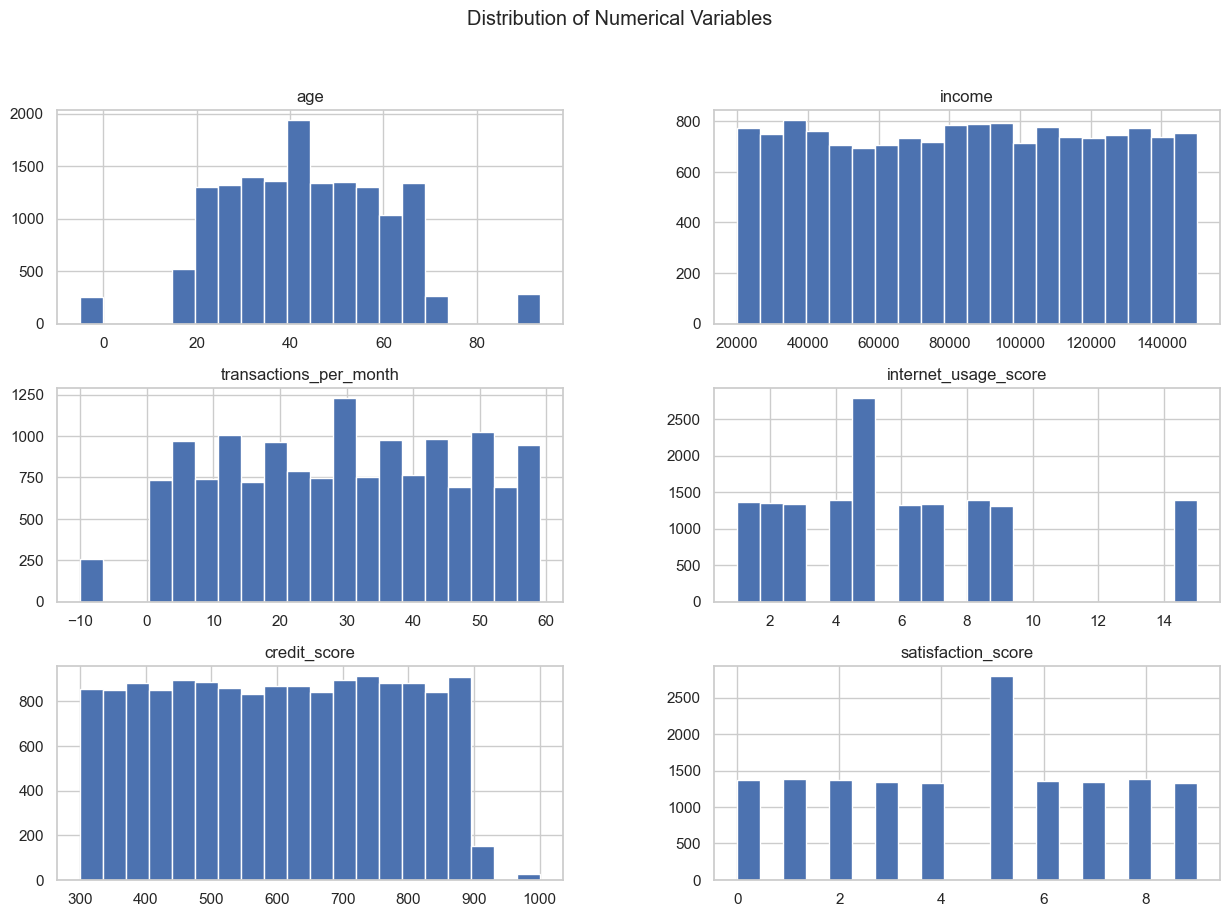

In [17]:
num_cols = ['age','income','transactions_per_month',
            'internet_usage_score','credit_score','satisfaction_score']

df[num_cols].hist(bins=20, figsize=(15,10))
plt.suptitle("Distribution of Numerical Variables")
plt.show()

## Analyze Relationships Between Variables

##  Correlation Analysis

Correlation shows how strongly variables are related.

Values range from:
- +1 → Strong positive
- -1 → Strong negative
- 0 → No relationship

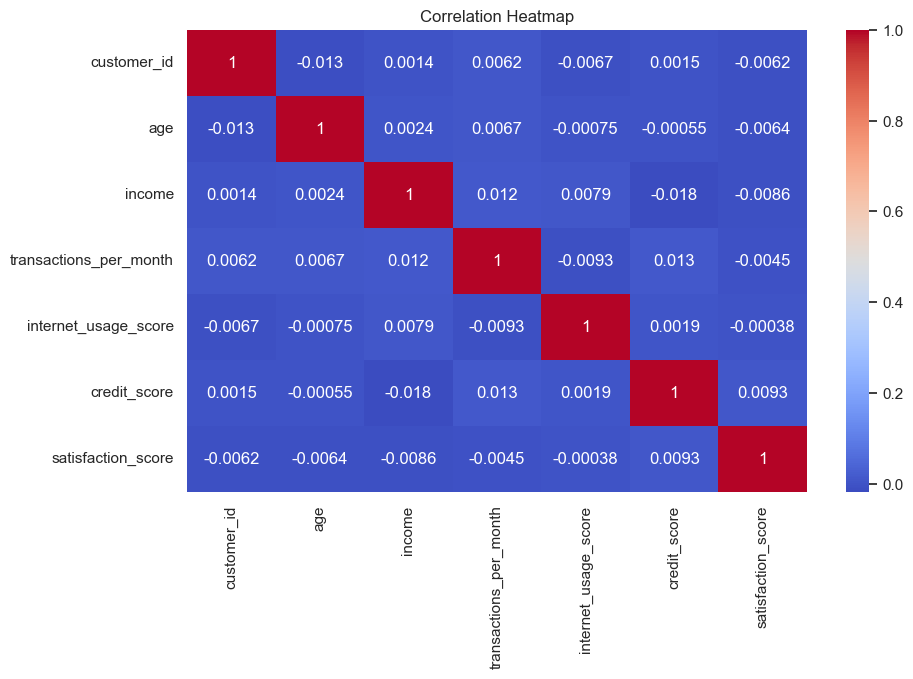

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering

##  Creating Age Group Feature

We convert the continuous `age` variable into categorical groups.

###  Why?
- Makes analysis easier
- Helps identify target customer segments
- Useful for business decision making

###  Age Groups:
- 18–25 → Young
- 26–35 → Young Adults
- 36–50 → Middle Age
- 51–65 → Senior
- 65+ → Elderly

In [19]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 25, 35, 50, 65, 100],
    labels=['18-25', '26-35', '36-50', '51-65', '65+']
)

# Check result
df[['age', 'age_group']].head()

,age,age_group
0,56.0,51-65
1,69.0,65+
2,46.0,36-50
3,32.0,26-35
4,60.0,51-65


In [20]:
df['age_group'].value_counts()

age_group
36-50    4627
51-65    3948
26-35    2735
18-25    1835
65+      1346
Name: count, dtype: int64

##  Creating Income Level Feature

We categorize income into levels using quantiles.

###  Why?
- Helps segment customers into economic groups
- Useful for targeting marketing strategies

###  Income Levels:
- Low
- Medium
- High

In [21]:
df['income_level'] = pd.qcut(
    df['income'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Check result
df[['income', 'income_level']].head()

,income,income_level
0,145056.0,High
1,47133.0,Low
2,44740.0,Low
3,120628.0,High
4,50976.0,Low


In [22]:
df['income_level'].value_counts()

income_level
Low       5000
Medium    5000
High      5000
Name: count, dtype: int64

In [23]:
print(df.columns)

Index(['customer_id', 'age', 'gender', 'income', 'city', 'location',
       'education', 'banking_type', 'transactions_per_month',
       'internet_usage_score', 'credit_score', 'satisfaction_score',
       'age_group', 'income_level'],
      dtype='object')


## VISUALIZATION

##  Business Question:

1. Online vs Offline Banking Users

This visualization shows the distribution of customers using online and offline banking services.

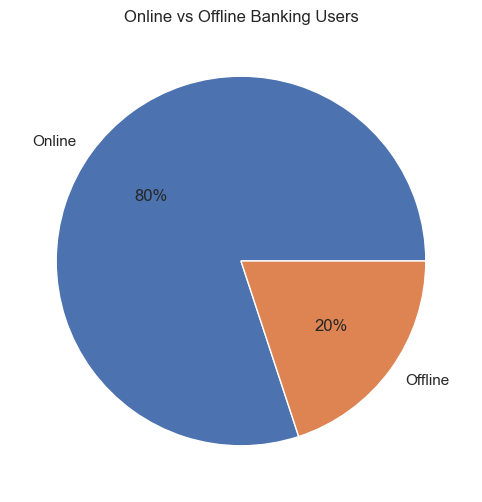

In [24]:
import matplotlib.pyplot as plt

counts = df["banking_type"].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.0f%%')
plt.title("Online vs Offline Banking Users")

plt.show()

-> Online banking has higher adoption compared to offline banking.                                                      
-> Customers are gradually shifting towards digital banking due to convenience and speed.

2. How does age group influence online vs offline banking usage?

This visualization shows the distribution of users across different age groups for online and offline banking. A stacked bar chart is used to compare how each age group prefers a particular banking method.

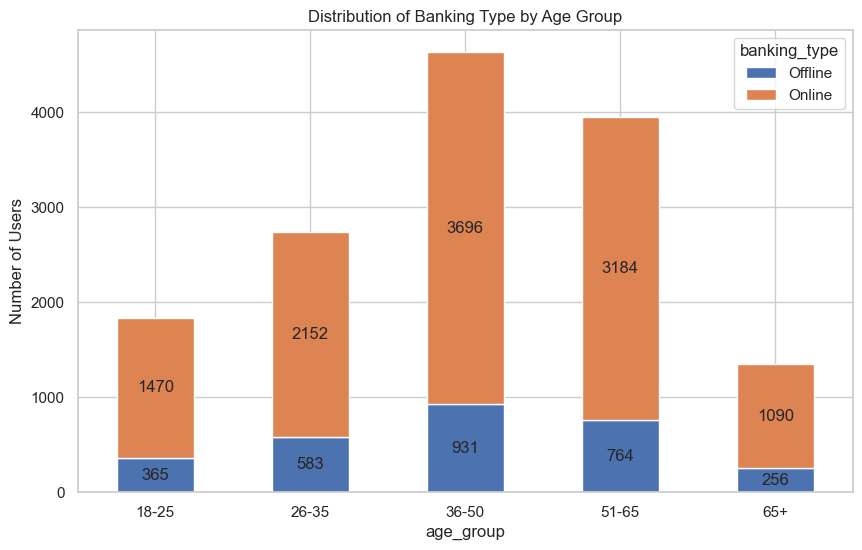

In [25]:
age_data = pd.crosstab(df["age_group"], df["banking_type"])

ax = age_data.plot(kind="bar", stacked=True)

for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.title("Distribution of Banking Type by Age Group")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)

plt.show()

-> Age group (36–50) strongly prefer online banking.

3. How does location influence online vs offline banking usage?

This visualization compares banking preferences of customers based on their location (Urban vs Rural). It shows how users from different areas choose between online and offline banking services.


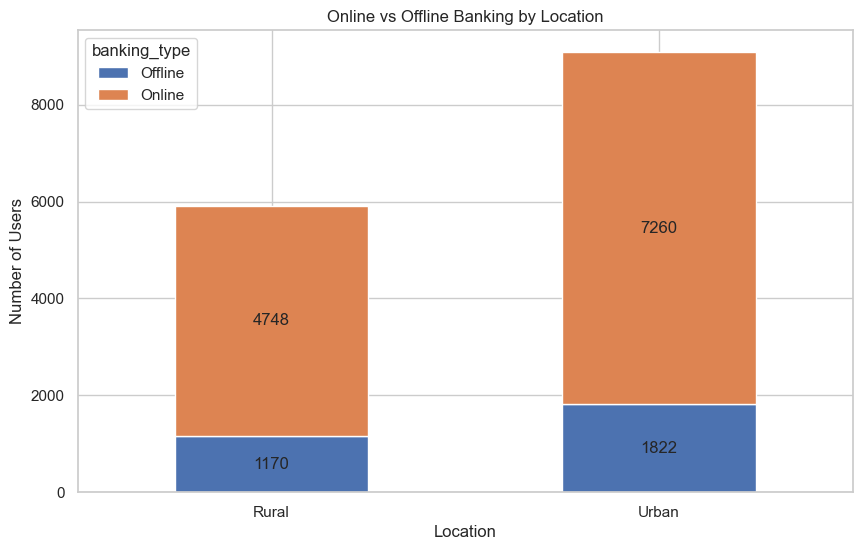

In [26]:

loc_data = df.groupby(["location", "banking_type"]).size().unstack()

ax = loc_data.plot(kind="bar", stacked=True)

for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.title("Online vs Offline Banking by Location")
plt.xlabel("Location")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)

plt.show()

-> Urban customers mostly prefer online banking.                                                                     
-> Internet access and digital awareness play a major role in this difference.

4.  Which are the top 10 cities with the highest banking usage and how do they differ in online vs offline adoption?

This visualization identifies the top 10 cities with the highest number of banking users 

In [27]:
top_cities = df["city"].value_counts().head(10)

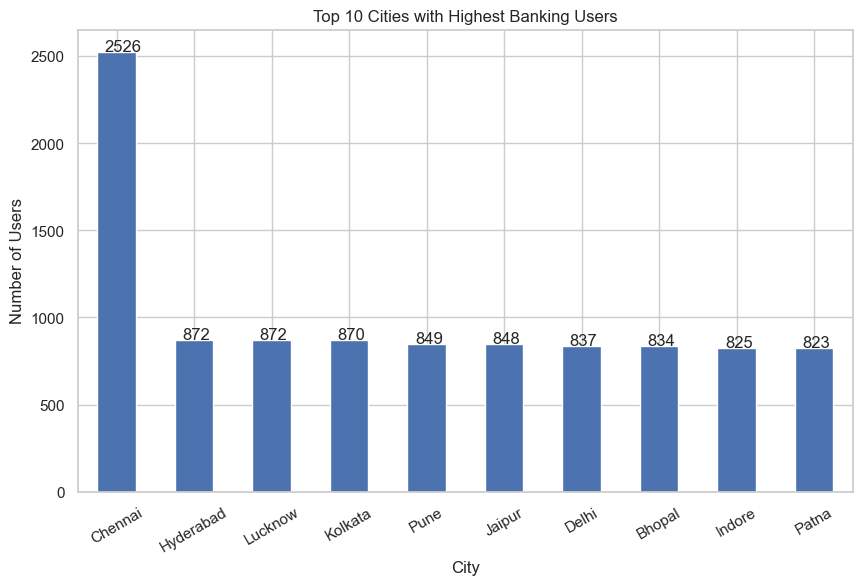

In [28]:

ax = top_cities.plot(kind="bar")

# Add labels
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x()+0.1, p.get_height()+5))

plt.title("Top 10 Cities with Highest Banking Users")
plt.xlabel("City")
plt.ylabel("Number of Users")
plt.xticks(rotation=30)

plt.show()

-> Metro cities show higher adoption of online banking, while some cities still rely on offline banking services.

5. How does income level influence online vs offline banking usage?

This visualization analyzes how customers from different income levels (High and Low) prefer online or offline banking services. 

C:\Users\Acer\AppData\Local\Temp\ipykernel_5452\1797444475.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_data = df.groupby(["income_level","banking_type"]).size().unstack()


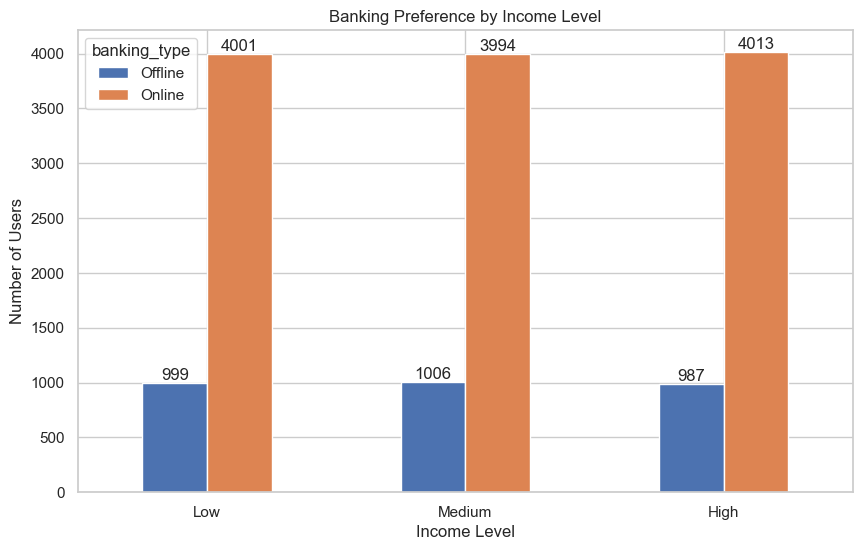

In [29]:

income_data = df.groupby(["income_level","banking_type"]).size().unstack()

ax = income_data.plot(kind="bar")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Banking Preference by Income Level")
plt.xlabel("Income Level")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)

plt.show()

-> Customers with higher income levels tend to prefer online banking.

6.  How do transactions per month differ between online and offline banking users?

This visualization compares the average number of transactions performed per month by customers using online and offline banking services. 

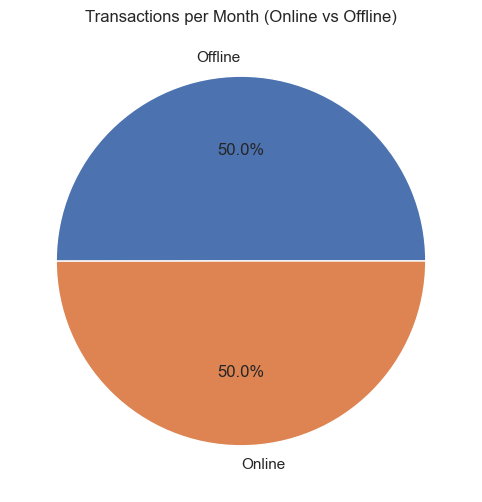

In [30]:
import matplotlib.pyplot as plt

df["banking_type"] = df["banking_type"].astype(str).str.strip().str.capitalize()

txn_data = df.groupby("banking_type")["transactions_per_month"].mean()

plt.pie(txn_data, labels=txn_data.index, autopct='%1.1f%%')

plt.title("Transactions per Month (Online vs Offline)")
plt.show()

-> Both Online banking users and Offline banking users perform same transactions per month.

7. How does customer satisfaction differ between online and offline banking?

This visualization compares the average satisfaction levels of customers using online and offline banking services. It helps in understanding which banking method provides a better customer experience.

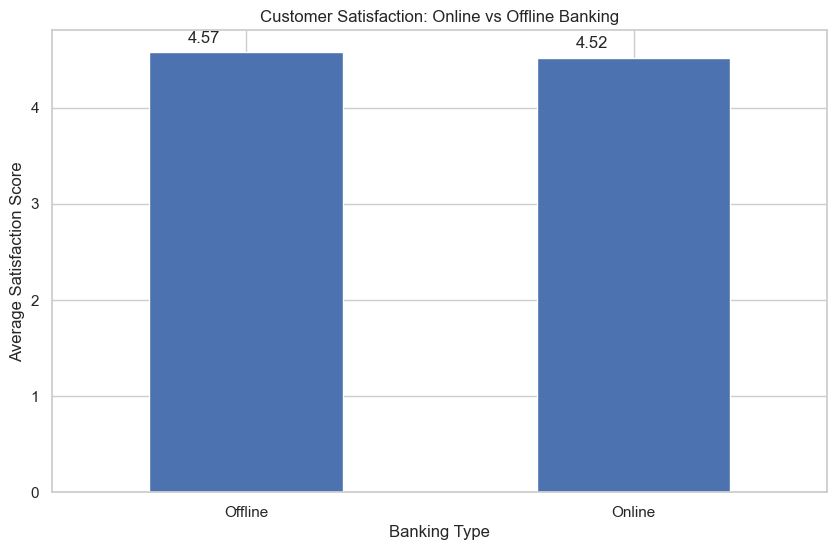

In [31]:


satisfaction = df.groupby("banking_type")["satisfaction_score"].mean()

ax = satisfaction.plot(kind="bar")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x()+0.1, p.get_height()+0.1))

plt.title("Customer Satisfaction: Online vs Offline Banking")
plt.xlabel("Banking Type")
plt.ylabel("Average Satisfaction Score")

plt.xticks(rotation=0)
plt.show()

-> Online banking users generally show higher satisfaction due to convenience and faster services, while offline banking may have lower satisfaction due to time and accessibility constraints.

8.  What is the relationship between different numerical variables in the dataset?

This visualization uses a correlation heatmap to show the strength and direction of relationships between numerical variables such as income, transactions, internet usage, credit score, and satisfaction score.

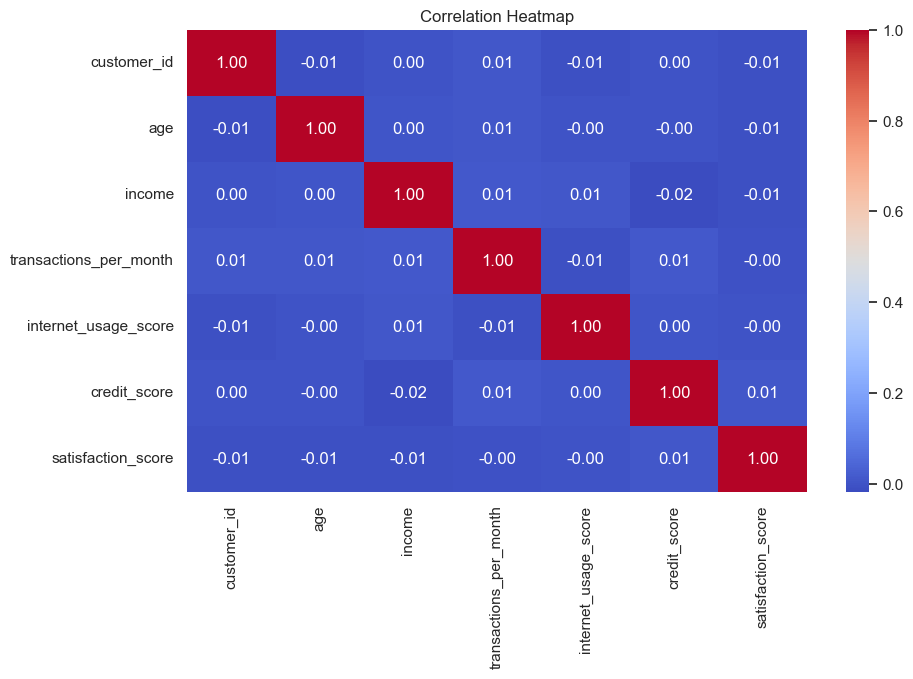

In [32]:

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

-> Values closer to 1 or -1 show strong relationships, while values near 0 show weak relationships.

9. How does credit score influence online vs offline banking usage?

This visualization analyzes the distribution of credit scores among customers using online and offline banking services. It helps in understanding whether customers with higher credit scores prefer digital banking over traditional methods.

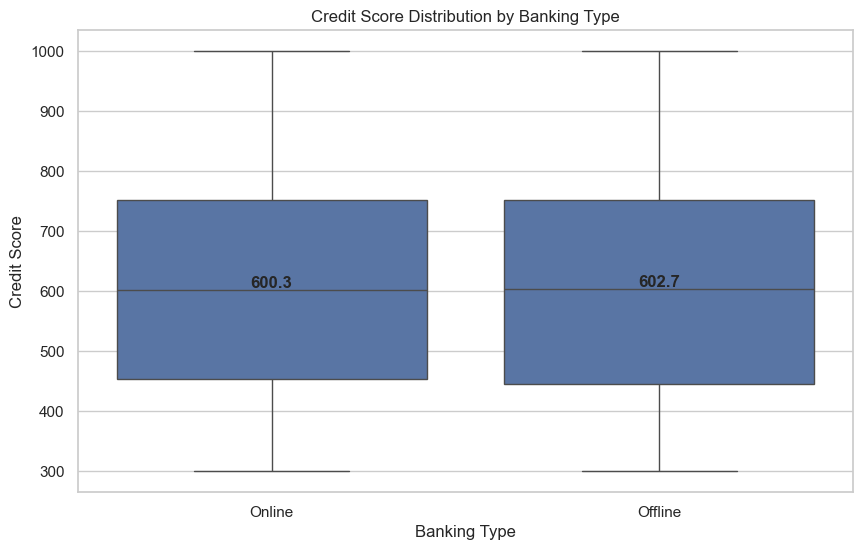

In [33]:

sns.boxplot(x="banking_type", y="credit_score", data=df)

means = df.groupby("banking_type")["credit_score"].mean()

for i, value in enumerate(means):
    plt.text(i, value, f"{value:.1f}", ha='center', va='bottom', fontweight='bold')

plt.title("Credit Score Distribution by Banking Type")
plt.xlabel("Banking Type")
plt.ylabel("Credit Score")

plt.show()

-> “Customers with higher credit scores tend to prefer online banking, indicating that financially stable users are more comfortable with digital services.”

In [34]:
df.to_csv("final_cleaned_data.csv", index=False)